# PubMed Systematic Review Pipeline

*Author: Regina Chua*

> This is the single notebook I run for the PubMed arm of my systematic review. I built it to be fully reproducible so my collaborators (and future me) can re-run the exact same search and analysis without guessing at parameters. Anything that defines *what* I'm searching for lives in `search_strategy.py`, I kept out of this notebook on purpose so the query stays identical (or up-to-date as I revise it) across every database I touch.

This notebook consolidates the previous `pubmed_pull` and `pubmed_exploration` notebooks
(now in `archive/`) into a single workflow with two goals:

1. **Collect** the set of articles that meet the search-strategy criteria from PubMed.
2. **Analyse** the resulting corpus with NLP (TF-IDF + n-gram ranking) to surface the key terms.

All inclusion/exclusion criteria live in `search_strategy.py` so the query stays consistent
across databases. Run the cells top-to-bottom.

**References:** PubMed access via [`pymed`](https://github.com/gijswobben/pymed).


## 1. Environment Setup

> Here I just pull in every library the pipeline needs and load my secrets from `.env`. My goal is to keep my PubMed contact email *out* of the code. PubMed asks for an email with each request (though it's not required at this time), and I don't want it committed to git so I read it from the environment instead. The print line is a quick sanity check that the email actually loaded before I start querying.


In [11]:
from datetime import datetime
from pathlib import Path
import json
import os
import re

from dotenv import load_dotenv
import numpy as np
import pandas as pd
from pymed import PubMed
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import plotly.express as px
    _HAS_PLOTLY = True
except Exception:
    _HAS_PLOTLY = False

# Load PUBMED_EMAIL (and any other secrets) from .env
load_dotenv()
pd.set_option("display.max_colwidth", 120)
print("Environment loaded. PUBMED_EMAIL set:", bool(os.getenv("PUBMED_EMAIL")))


Environment loaded. PUBMED_EMAIL set: True


## 2. Search Strategy

>This is the heart of the review and the part I'm most careful about. Rather than hard-coding a query string (as I did in the exploration script), I import my inclusion/exclusion terms from `search_strategy.py` and build the boolean query from them. My goal is to have **one single source of truth**: when I (or my supervisors) refine the terms, I only edit `search_strategy.py` and every database notebook stays in sync. The structure is essentially `(disease) AND (spatial) AND (exposure) NOT (exclusions)`, which mirrors my review scope: a neurodegenerative disease, a spatial/geographic angle, and an environmental exposure.

In [12]:
from search_strategy import (
    INCLUSION_CRITERIA,
    EXCLUSION_TERMS,
    DATE_FILTER,
    CLEANING_RULES,
    ALTERNATE_TERMS,
    NLP_SUGGESTED_EXPANSIONS,
)


def or_group(terms):
    """Quote each term and join with OR inside parentheses."""
    return "(" + " OR ".join(f'\"{t}\"' for t in terms) + ")"


def build_pubmed_query(inclusion, exclusion):
    """Compose the PubMed boolean query from the centralized search strategy.

    Structure: (disease) AND (spatial) AND (exposure) NOT (exclusions)
    """
    include = " AND ".join([
        or_group(inclusion["disease"]),
        or_group(inclusion["spatial"]),
        or_group(inclusion["exposure"]),
    ])
    return f"{include} NOT {or_group(exclusion)}"


def merge_terms(primary, alternates):
    """Combine primary inclusion terms with alternate/NLP-suggested terms per
    category (order-preserving, case-insensitive de-duplication)."""
    merged = {}
    for category, base_terms in primary.items():
        seen, combined = set(), []
        for t in list(base_terms) + list(alternates.get(category, [])):
            if t.lower() not in seen:
                seen.add(t.lower())
                combined.append(t)
        merged[category] = combined
    return merged


# Fold the NLP-suggested ALTERNATE_TERMS into the inclusion criteria so the
# query reflects the expanded vocabulary. Set this to False to fall back to the
# core criteria only (useful for comparing search sensitivity).
INCLUDE_ALTERNATE_TERMS = True
search_criteria = (
    merge_terms(INCLUSION_CRITERIA, ALTERNATE_TERMS)
    if INCLUDE_ALTERNATE_TERMS
    else INCLUSION_CRITERIA
)

query = build_pubmed_query(search_criteria, EXCLUSION_TERMS)
start_date = DATE_FILTER["start_date"]
end_date = DATE_FILTER["end_date"]

print("Date window:", start_date, "to", end_date)
print("Alternate terms folded into query:", INCLUDE_ALTERNATE_TERMS)
for category, term_list in search_criteria.items():
    print(f"{category} terms ({len(term_list)}):", term_list)
print("\nQuery:\n", query)

Date window: 2020-01-01 to 2025-12-31

Query:
 ("parkinson* disease" OR "neurodegenerative disease") AND ("geospatial" OR "spatial dependence" OR "spatiotemporal" OR "geographic" OR "environment*" OR "atmospheric" OR "spatial analysis") AND ("pollution" OR "chemical" OR "pesticide" OR "air pollution" OR "microplastic pollution" OR "traffic pollution" OR "water pollution" OR "trichloroethylene") NOT ("pathology" OR "treatment" OR "therapy" OR "intervention" OR "physiology" OR "monitoring" OR "biosensor" OR "animal" OR "plant" OR "in vitro" OR "molecular" OR "protein" OR "mice" OR "parkinson* disease model" OR "respiratory" OR "resistance training" OR "aggression")


## 3. Helper Functions

>These are the small utilities I lean on throughout the notebook. I define them once, up front, so the rest of the workflow stays readable (and to avoid the bug I had in the old notebook where a helper was trapped inside an `if` block - ah well, live and learn). `article_to_flat_dict` flattens the messy `pymed` objects into plain rows, and `row_to_text` / `normalize_term` give me clean, combined text per article for the NLP step. My goal here is to handle missing fields, list-valued keywords, and odd data types without crashing the run.


In [13]:
def is_empty(obj):
    """Safe emptiness check for lists, Series, numpy/sparse arrays."""
    if obj is None:
        return True
    try:
        return len(obj) == 0
    except Exception:
        pass
    try:
        return getattr(obj, "size", 0) == 0
    except Exception:
        return False


def article_to_flat_dict(article):
    """Flatten a pymed article object into a plain dict."""
    try:
        raw = article.toJSON()
        if isinstance(raw, str):
            return json.loads(raw)
        if isinstance(raw, dict):
            return raw
    except Exception:
        pass
    return {
        "pubmed_id": getattr(article, "pubmed_id", None),
        "title": getattr(article, "title", None),
        "publication_date": str(getattr(article, "publication_date", "") or ""),
        "keywords": getattr(article, "keywords", None),
        "abstract": getattr(article, "abstract", None),
        "doi": getattr(article, "doi", None),
    }


def _coerce_text(val):
    """Normalize a single field value to a string (handles NA / list / ndarray)."""
    if val is None:
        return ""
    if isinstance(val, float) and np.isnan(val):
        return ""
    if isinstance(val, np.ndarray):
        return " ".join(map(str, val.tolist())) if val.size else ""
    if isinstance(val, (list, tuple)):
        return " ".join(map(str, val)) if len(val) else ""
    return str(val)


def row_to_text(row, cols=("title", "abstract", "keywords")):
    """Combine the chosen text columns of a row into one string."""
    get = row.get if isinstance(row, dict) else (lambda c, d="": row[c] if c in row else d)
    parts = [_coerce_text(get(c, "")) for c in cols]
    return " ".join(p for p in parts if p)


def normalize_term(s):
    s = re.sub(r"[^a-z0-9\s]", " ", s.lower())
    return re.sub(r"\s+", " ", s).strip()


## 4. Collect Articles from PubMed

>This is the actual data collection step. I send my query to PubMed, flatten the results into a DataFrame, and then restrict to the date window from `search_strategy.py` (currently a 5-year window). I keep `results` as a list so I can re-use it without re-hitting the API. The two printed counts (total returned vs. within the date window) are my first checkpoint that the search behaved as expected.


In [14]:
# PubMed kindly requests a tool name and contact email
# https://www.ncbi.nlm.nih.gov/pmc/tools/developers/
pubmed = PubMed(tool="SystematicReview", email=os.getenv("PUBMED_EMAIL"))

MAX_RESULTS = 500

# Convert to a list so results can be iterated multiple times (not exhausted)
results = list(pubmed.query(query, max_results=MAX_RESULTS))
df_results = pd.json_normalize([article_to_flat_dict(a) for a in results])

# Restrict to the configured date window
df_results["publication_date"] = pd.to_datetime(
    df_results["publication_date"], format="ISO8601", errors="coerce"
)
mask = df_results["publication_date"] >= start_date
if end_date:
    mask &= df_results["publication_date"] <= end_date
df_filtered = df_results[mask].copy()

preview_cols = [c for c in ["title", "abstract", "publication_date", "keywords"]
                if c in df_results.columns]

print("Total articles returned:", df_results.shape[0])
print("Articles within date window:", df_filtered.shape[0])
display(df_filtered[preview_cols].head())


Total articles returned: 287
Articles within date window: 128


,title,abstract,publication_date,keywords
14,Agricultural Copper Pesticide Exposure and Metabolic Profiles among Parkinson's Disease Cases and Community Controls...,Copper-based pesticide exposures have been linked to increased Parkinson's disease (PD) risk through oxidative stres...,2025-12-29,[]
15,"Short-term associations between ambient air pollution and emergency department visits for Parkinson disease, multipl...","Previous studies have linked ambient air pollution to worsening neurological conditions, but research in the United ...",2025-12-26,"[Air pollution, Emergency department visits, Health effect, Migraine, Multiple sclerosis, Parkinson disease, Seizure]"
16,Air pollution and disease progression in a University of Michigan amyotrophic lateral sclerosis cohort.,"Amyotrophic lateral sclerosis (ALS) is a rare, fatal, neurodegenerative disease without effective treatments. Theref...",2025-11-25,"[ALSFRS-R, Air pollution, Amyotrophic lateral sclerosis, Black carbon, Nitrate, Ozone, PM(2.5)]"
17,Air pollution and Parkinson's disease: A prospective cohort study with sex-stratified analysis in the UK biobank.,"Air pollution has been suggested as a potential environmental risk factor for Parkinson's disease (PD), but findings...",2025-11-21,"[Air Pollution, Nitrogen Dioxide, Parkinson’s Disease, Particulate Matter, Sex Difference]"
18,Environmental toxins in neurodegeneration - a narrative review.,As the global incidence of neurodegenerative disorders rises at a rate beyond what can be attributed solely to popul...,2025-11-18,"[Air pollution, Alzheimer’s disease, Amyotrophic lateral sclerosis, Environmental toxins, Heavy metals, Neurodegener..."


## 5. Clean Results

>Time to tidy the raw pull. I drop duplicate titles, and I require both a PubMed ID and a DOI so every article is uniquely identifiable and traceable for screening. I drive these rules from `CLEANING_RULES` in `search_strategy.py`.

In [15]:
if CLEANING_RULES.get("remove_duplicate_titles", True):
    df_filtered = df_filtered.drop_duplicates(subset=["title"])
if CLEANING_RULES.get("require_pubmed_id", True) and "pubmed_id" in df_filtered.columns:
    df_filtered = df_filtered.dropna(subset=["pubmed_id"])
if CLEANING_RULES.get("require_doi", True) and "doi" in df_filtered.columns:
    df_filtered = df_filtered.dropna(subset=["doi"])

print("Articles after cleaning:", df_filtered.shape[0])
display(df_filtered[preview_cols].head())

Articles after cleaning: 127


,title,abstract,publication_date,keywords
14,Agricultural Copper Pesticide Exposure and Metabolic Profiles among Parkinson's Disease Cases and Community Controls...,Copper-based pesticide exposures have been linked to increased Parkinson's disease (PD) risk through oxidative stres...,2025-12-29,[]
15,"Short-term associations between ambient air pollution and emergency department visits for Parkinson disease, multipl...","Previous studies have linked ambient air pollution to worsening neurological conditions, but research in the United ...",2025-12-26,"[Air pollution, Emergency department visits, Health effect, Migraine, Multiple sclerosis, Parkinson disease, Seizure]"
16,Air pollution and disease progression in a University of Michigan amyotrophic lateral sclerosis cohort.,"Amyotrophic lateral sclerosis (ALS) is a rare, fatal, neurodegenerative disease without effective treatments. Theref...",2025-11-25,"[ALSFRS-R, Air pollution, Amyotrophic lateral sclerosis, Black carbon, Nitrate, Ozone, PM(2.5)]"
17,Air pollution and Parkinson's disease: A prospective cohort study with sex-stratified analysis in the UK biobank.,"Air pollution has been suggested as a potential environmental risk factor for Parkinson's disease (PD), but findings...",2025-11-21,"[Air Pollution, Nitrogen Dioxide, Parkinson’s Disease, Particulate Matter, Sex Difference]"
18,Environmental toxins in neurodegeneration - a narrative review.,As the global incidence of neurodegenerative disorders rises at a rate beyond what can be attributed solely to popul...,2025-11-18,"[Air pollution, Alzheimer’s disease, Amyotrophic lateral sclerosis, Environmental toxins, Heavy metals, Neurodegener..."


## 6. Export Cleaned Results

>I save the cleaned set to CSV so it becomes the stable hand-off artifact for the screening stage and for merging with the other database results later. Exporting here means I can pick the analysis back up from the CSV without re-querying PubMed.

In [16]:
output_csv_path = Path("pubmed_results_cleaned_2026.csv")
df_filtered.to_csv(output_csv_path, index=False)
print(f"Exported {len(df_filtered)} cleaned articles to {output_csv_path.resolve()}")


Exported 127 cleaned articles to /mnt/c/Users/ReginaChua/Desktop/sysrev/pubmed_results_cleaned_2026.csv


## 7. NLP Analysis to Identify Key Terms

>Now the NLP lift! I combine each article's title, abstract, and keywords into a corpus, then rank 1–3 gram terms by a blend of **TF-IDF** (importance, down-weighting words that appear everywhere) and raw **frequency**. My aim is to surface vocabulary I might have missed so I can sensibly expand the search strategy into `suggest_expansions()` gives me a shortlist of candidate terms, and I deliberately exclude anything already in my query so I only see *new* ideas.

In [17]:
# Fall back to the exported CSV if the collection cells were not run this session
if "df_filtered" not in globals() or is_empty(df_filtered):
    df_filtered = pd.read_csv("pubmed_results_cleaned_2025.csv")
    print("Loaded df_filtered from CSV")

corpus = [row_to_text(r) for r in df_filtered.to_dict(orient="records")]
print(f"Built corpus with {len(corpus)} documents")

NGRAM_RANGE = (1, 3)
MAX_DF = 0.9

tfidf_vec = TfidfVectorizer(ngram_range=NGRAM_RANGE, stop_words="english", max_df=MAX_DF)
X = tfidf_vec.fit_transform(corpus)
feature_names = tfidf_vec.get_feature_names_out()
tfidf_scores = np.asarray(X.sum(axis=0)).ravel()

count_vec = CountVectorizer(ngram_range=NGRAM_RANGE, stop_words="english")
Y = count_vec.fit_transform(corpus)
counts = np.asarray(Y.sum(axis=0)).ravel()

tfidf_df = pd.DataFrame({"term": feature_names, "tfidf": tfidf_scores})
freq_df = pd.DataFrame({"term": count_vec.get_feature_names_out(), "count": counts})

terms = tfidf_df.merge(freq_df, on="term", how="outer").fillna(0)
terms["ngram_len"] = terms["term"].str.count(" ") + 1

# Combined score: mostly TF-IDF, with a frequency boost
terms["score"] = terms["tfidf"] * 0.7 + (terms["count"] / (terms["count"].max() + 1e-9)) * 0.3

# Drop terms already in the query, single characters, and pure numbers
existing = {normalize_term(t) for t in re.findall(r"[A-Za-z*]+(?:\s+[A-Za-z*]+)*", query)}
terms["term_norm"] = terms["term"].apply(normalize_term)
terms = terms[~terms["term_norm"].isin(existing)]
terms = terms[terms["term"].str.len() > 2]
terms = terms[~terms["term"].str.match(r"^\d+$")]

print(f"Computed scores for {len(terms)} candidate n-grams")

Built corpus with 127 documents
Computed scores for 31428 candidate n-grams


In [18]:
def suggest_expansions(n=20, min_count=2, ngram_len=None):
    """Return the top-scoring candidate terms to consider adding to the query."""
    s = terms[terms["count"] >= min_count]
    if ngram_len is not None:
        s = s[s["ngram_len"] == ngram_len]
    return s.sort_values("score", ascending=False)["term"].head(n).tolist()


display_cols = ["term", "ngram_len", "count", "tfidf", "score"]

print("Top 20 key terms (combined score):")
display(terms.sort_values("score", ascending=False)[display_cols].head(20).reset_index(drop=True))

for n in (1, 2):
    print(f"\nTop single/multi-word terms (ngram_len={n}):")
    display(
        terms[terms["ngram_len"] == n]
        .sort_values("score", ascending=False)[display_cols]
        .head(10)
        .reset_index(drop=True)
    )

live_suggestions = suggest_expansions()
print("\nSuggested expansion terms (live):", live_suggestions)

# Cross-reference against the snapshot persisted in search_strategy.py.
# The domain-relevant terms below have been folded into ALTERNATE_TERMS for
# sensitivity analyses; the full ranked snapshot lives in NLP_SUGGESTED_EXPANSIONS.
stored = NLP_SUGGESTED_EXPANSIONS["top_20"]
new_vs_stored = [t for t in live_suggestions if t not in stored]
print("Stored snapshot (search_strategy.NLP_SUGGESTED_EXPANSIONS['top_20']):", stored)
print("Live terms not in stored snapshot:", new_vs_stored or "none — snapshot is up to date")

print("\nALTERNATE_TERMS available for sensitivity analyses:")
for category, term_list in ALTERNATE_TERMS.items():
    print(f"  {category}: {term_list}")


Top 20 key terms (combined score):


,term,ngram_len,count,tfidf,score
0,exposure,1,291,3.718406,2.840759
1,air,1,187,3.766825,2.789639
2,parkinson,1,240,3.593937,2.711942
3,risk,1,210,2.997678,2.270036
4,dementia,1,112,2.380560,1.757945
5,study,1,158,2.242181,1.698682
6,factors,1,103,2.072738,1.535113
7,environmental,1,115,2.052287,1.530606
8,neurodegenerative,1,109,1.913430,1.428502
9,association,1,96,1.901553,1.409562



Top single/multi-word terms (ngram_len=1):


,term,ngram_len,count,tfidf,score
0,exposure,1,291,3.718406,2.840759
1,air,1,187,3.766825,2.789639
2,parkinson,1,240,3.593937,2.711942
3,risk,1,210,2.997678,2.270036
4,dementia,1,112,2.380560,1.757945
5,study,1,158,2.242181,1.698682
6,factors,1,103,2.072738,1.535113
7,environmental,1,115,2.052287,1.530606
8,neurodegenerative,1,109,1.913430,1.428502
9,association,1,96,1.901553,1.409562



Top single/multi-word terms (ngram_len=2):


,term,ngram_len,count,tfidf,score
0,alzheimer disease,2,50,1.337850,0.977367
1,long term,2,46,1.300090,0.947665
2,particulate matter,2,39,1.299250,0.941355
3,disease pd,2,61,1.084976,0.809347
4,95 ci,2,51,1.034866,0.766096
5,pesticide exposure,2,38,1.048295,0.764869
6,neurodegenerative diseases,2,37,0.920863,0.674849
7,meta analysis,2,25,0.873543,0.631916
8,term exposure,2,28,0.863318,0.627211
9,risk factors,2,30,0.846034,0.616747



Suggested expansion terms (live): ['exposure', 'air', 'parkinson', 'risk', 'dementia', 'study', 'factors', 'environmental', 'neurodegenerative', 'association', 'studies', 'pesticides', 'alzheimer', 'term', 'particulate', 'diseases', 'review', 'analysis', 'associated', 'alzheimer disease']
Stored snapshot (search_strategy.NLP_SUGGESTED_EXPANSIONS['top_20']): ['exposure', 'air', 'parkinson', 'risk', 'dementia', 'study', 'factors', 'environmental', 'neurodegenerative', 'association', 'studies', 'pesticides', 'diseases', 'alzheimer', 'particulate', 'term', 'associated', 'review', 'analysis', 'matter']
Live terms not in stored snapshot: ['alzheimer disease']

ALTERNATE_TERMS available for sensitivity analyses:
  disease: ['movement disorders', 'extrapyramidal disorders', 'dementia', 'alzheimer disease', 'cognitive impairment', 'amyotrophic lateral sclerosis']
  spatial: ['spatial analysis', 'geospatial analysis', 'geographic information systems', 'GIS', 'spatial epidemiology']
  exposure: 

## 8. Visualise Key Terms

>Finally I visualise the key terms so the patterns are easy to read at a glance and to drop into decks. The first heatmap compares normalized TF-IDF vs. frequency for the top terms (helps me spot terms that are *distinctive* rather than just common), and the second shows TF-IDF intensity per term across individual papers so I can see which articles are driving a given term.

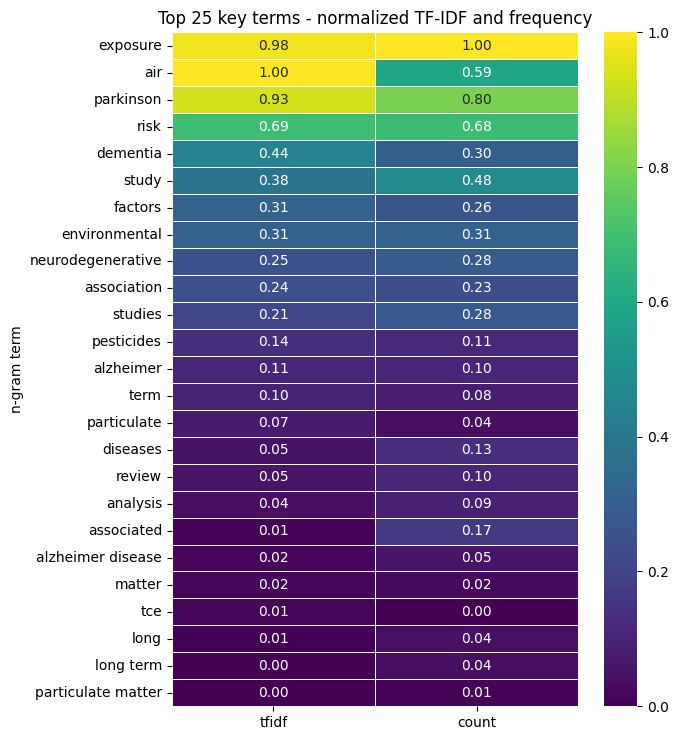

In [19]:
TOP_N_TERMS = 25

top_terms = terms.sort_values("score", ascending=False).head(TOP_N_TERMS).set_index("term")

# Normalized TF-IDF vs frequency for the top terms
heat = top_terms[["tfidf", "count"]].copy()
for col in heat.columns:
    rng = heat[col].max() - heat[col].min()
    heat[col] = (heat[col] - heat[col].min()) / (rng + 1e-9)

plt.figure(figsize=(7, max(6, len(heat) * 0.3)))
sns.heatmap(heat, cmap="viridis", annot=True, fmt=".2f", linewidths=0.4, linecolor="white")
plt.title(f"Top {len(heat)} key terms - normalized TF-IDF and frequency")
plt.ylabel("n-gram term")
plt.tight_layout()
plt.show()


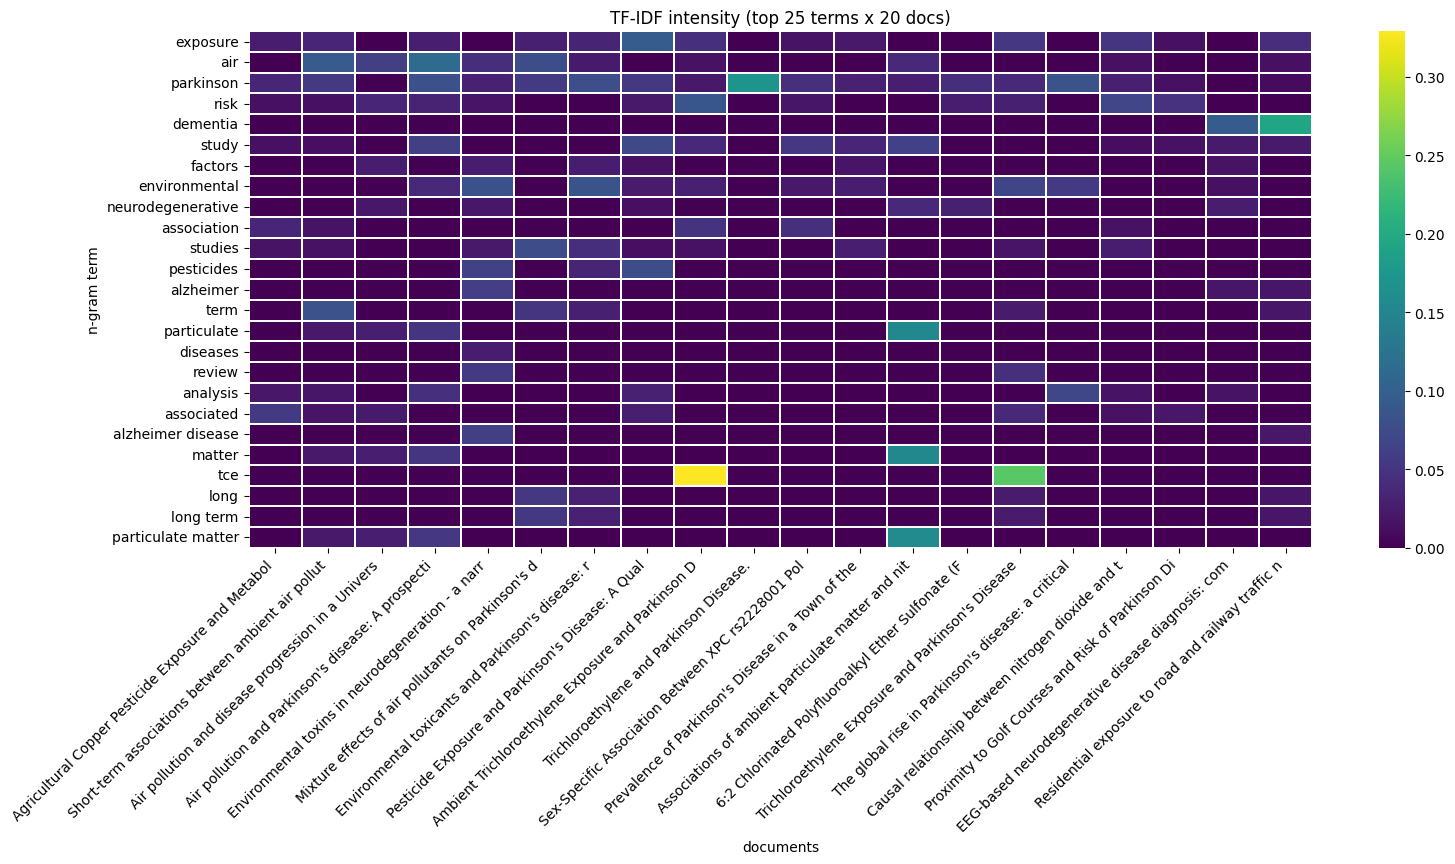

In [20]:
# Term x document TF-IDF intensity for the top terms across the first N documents
MAX_DOCS = 20

term_to_idx = {t: i for i, t in enumerate(feature_names)}
selected = [term_to_idx[t] for t in top_terms.index if t in term_to_idx]
doc_idx = list(range(min(X.shape[0], MAX_DOCS)))

mat = X[doc_idx, :][:, selected].toarray().T  # terms x docs
term_labels = [feature_names[i] for i in selected]
doc_titles = (
    df_filtered.iloc[doc_idx]["title"].fillna("").astype(str).str.slice(0, 50).tolist()
)

plt.figure(figsize=(max(10, len(doc_titles) * 0.8), max(6, len(term_labels) * 0.35)))
sns.heatmap(mat, yticklabels=term_labels, xticklabels=doc_titles, cmap="viridis", linewidths=0.3)
plt.title(f"TF-IDF intensity (top {len(term_labels)} terms x {len(doc_titles)} docs)")
plt.xlabel("documents")
plt.ylabel("n-gram term")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

if _HAS_PLOTLY:
    fig = px.imshow(mat, x=doc_titles, y=term_labels, color_continuous_scale="Viridis")
    fig.update_layout(title="Interactive TF-IDF intensity", xaxis={"tickangle": -45})
    try:
        fig.show()
    except ValueError as e:
        # Interactive Plotly rendering needs nbformat>=4.2.0 in the kernel.
        # The static seaborn heatmap above already shows the same data.
        print("Skipping interactive Plotly chart -", e)
        print("To enable it, install nbformat in this kernel: pip install nbformat")
